# **AI3170 - Machine Learning (1)**
**Assignment 1**


---



Aliyah Alabdali

Rahaf Almalki

Dr. Afaf Almehmadi


---



# Data Exploration and Preprocessing




a) Load the California Housing dataset from scikit-learn.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load the dataset
# The as_frame=True argument is used to return the dataset as a pandas DataFrame instead of the default NumPy array.
housing_data = fetch_california_housing(as_frame=True)
data = housing_data.frame

b) Perform basic exploratory data analysis (EDA).

In [ ]:
# Get the number of rows and columnsin the dataset
print(f"The dataset contains {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset contains 20640 rows and 9 columns.


In [ ]:
# Display the first 10 rows of the dataset
data.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [ ]:
# Check for missing values
data.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
# Calculate the mean for each numerical column
mean_values = data.mean()
print("Mean values:\n", mean_values)

# Calculate the median for each numerical column
median_values = data.median()
print("\nMedian values:\n", median_values)

# Calculate the standard deviation for each numerical column
std_values = data.std()
print("\nStandard Deviation:\n", std_values)

Mean values:
 MedInc            3.870671
HouseAge         28.639486
AveRooms          5.429000
AveBedrms         1.096675
Population     1425.476744
AveOccup          3.070655
Latitude         35.631861
Longitude      -119.569704
MedHouseVal       2.068558
dtype: float64

Median values:
 MedInc            3.534800
HouseAge         29.000000
AveRooms          5.229129
AveBedrms         1.048780
Population     1166.000000
AveOccup          2.818116
Latitude         34.260000
Longitude      -118.490000
MedHouseVal       1.797000
dtype: float64

Standard Deviation:
 MedInc            1.899822
HouseAge         12.585558
AveRooms          2.474173
AveBedrms         0.473911
Population     1132.462122
AveOccup         10.386050
Latitude          2.135952
Longitude         2.003532
MedHouseVal       1.153956
dtype: float64


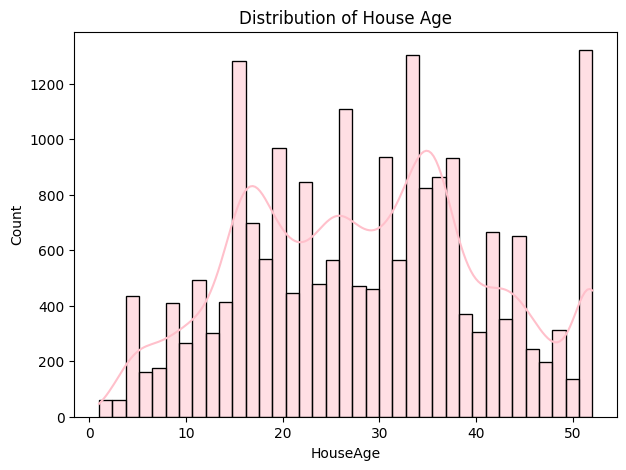

In [ ]:
# Visualizations
# Histogram for 'HouseAge' column
plt.figure(figsize=(7,5))
sns.histplot(data['HouseAge'], kde=True,color='pink')
plt.title('Distribution of House Age')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


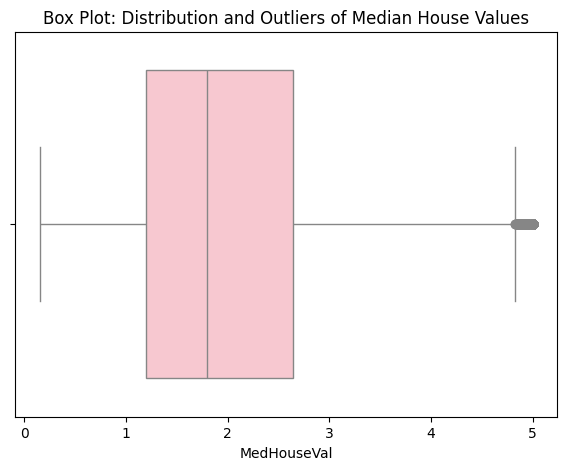

In [ ]:
# We use Box plot of house values to visualize the distribution of data and detect outliers.
plt.figure(figsize=(7,5))
sns.boxplot(x=data['MedHouseVal'],color='pink')
plt.title('Box Plot: Distribution and Outliers of Median House Values')
plt.show()

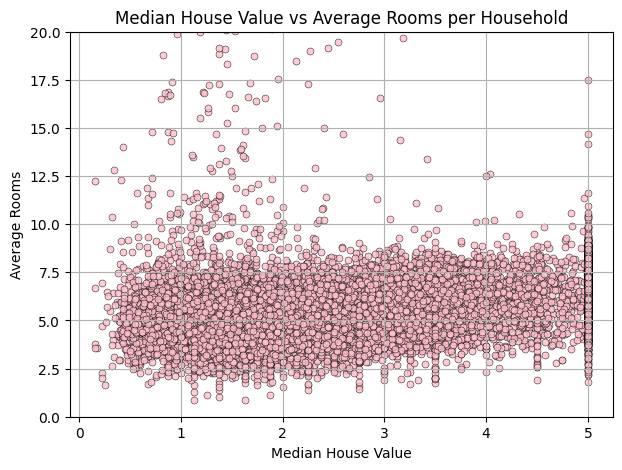

In [ ]:
# We use a scatter plot to show the relationship between Median House Value and Average Rooms,
# while limiting the y-axis to remove outliers and improve readability.
plt.figure(figsize=(7,5))

# Create a scatter plot of Median House Value vs Average Rooms with enhanced settings
sns.scatterplot(data=data, x='MedHouseVal', y='AveRooms', color='pink', s=25, alpha=0.8, edgecolor='black')

# Set the label for the x-axis as 'Median House Value'
plt.xlabel('Median House Value')

# Set the label for the y-axis as 'Average Rooms per Household'
plt.ylabel('Average Rooms')

# Set a title
plt.title('Median House Value vs Average Rooms per Household')

# Adjusting the y-axis to limit the values and exclude extreme outliers
plt.ylim(0, 20)

# Display gridlines
plt.grid(True)

# Show the plot
plt.show()


c) Preprocess the data:

In [ ]:
# Create binary classification target: expensive if value is above the median
median_value = data['MedHouseVal'].median()
data['Expensive'] = data['MedHouseVal'].apply(lambda x: 'expensive' if x > median_value else 'not expensive')
# Normalize numerical features
scaler = StandardScaler()
numerical_cols = data.drop(columns=['MedHouseVal', 'Expensive']).columns
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

In [ ]:
data.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Expensive
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,expensive
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,expensive
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,expensive
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,expensive
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,expensive


# Logistic Regression for Classification




a) Split the data into training and testing sets (use 80% for training, 20% for testing).

In [ ]:
# X: Feature matrix (drop 'MedHouseVal' and 'Expensive')
X = data.drop(columns=['MedHouseVal', 'Expensive'])
# y: Target column ('Expensive' or not)
y = data['Expensive']

# Create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Select the best features using SelectKBest
selector = SelectKBest(score_func=f_classif, k='all')  # Use k='all' to get all features for now
X_selected = selector.fit_transform(X_poly, y)

# Display selected features scores
feature_scores = selector.scores_
print("Feature scores:", feature_scores)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Step 4: Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Feature scores: [7.73116417e+03 1.00947565e+02 1.84283633e+02 6.98265960e+01
 1.25287683e-04 1.28954036e+01 4.11459236e+02 4.09155631e+01
 4.33986530e+00 4.15166286e+02 9.77813233e+00 3.13135985e+01
 1.17352856e+00 1.06244119e+01 5.22060820e+00 6.80074614e-01
 1.55793705e+01 2.53074745e+01 2.40362375e+00 1.16562696e+02
 4.61032461e+01 1.43616520e+00 1.14569290e+01 7.90861008e+00
 3.82696187e+01 1.26239567e+01 2.67862600e+01 7.05439055e+00
 1.21993584e+01 1.92503362e-01 6.84106097e-01 9.05076761e+01
 3.44137512e+01 2.42609331e-02 1.99614516e-02 2.56790546e+02]


b) Train a logistic regression model to predict whether a house is '**expensive**' or '**not expensive**'.

In [ ]:
# Initialize the model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

c) Make predictions on the test set.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

d) Evaluate the model's performance using:
*    Accuracy score
*    Confusion matrix
*    Classification report (precision, recall, F1-score)
*   ROC-AUC





In [ ]:
# Evaluate the model's performance using:
# accuracy score:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix:
conf_matrix = confusion_matrix(y_test, y_pred)

# Classification report (precision, recall, F1-score):
report = classification_report(y_test, y_pred)
print(report)

# ROC-AUC:
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC: {roc_auc:.2f}")

# Generate ROC curve and specify that 'expensive' is the positive label
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1], pos_label='expensive')

Accuracy: 84.88%
               precision    recall  f1-score   support

    expensive       0.85      0.84      0.85      2051
not expensive       0.85      0.86      0.85      2077

     accuracy                           0.85      4128
    macro avg       0.85      0.85      0.85      4128
 weighted avg       0.85      0.85      0.85      4128

ROC-AUC: 0.93


e) Use confusion matrices and ROC curves to visually represent model performance.

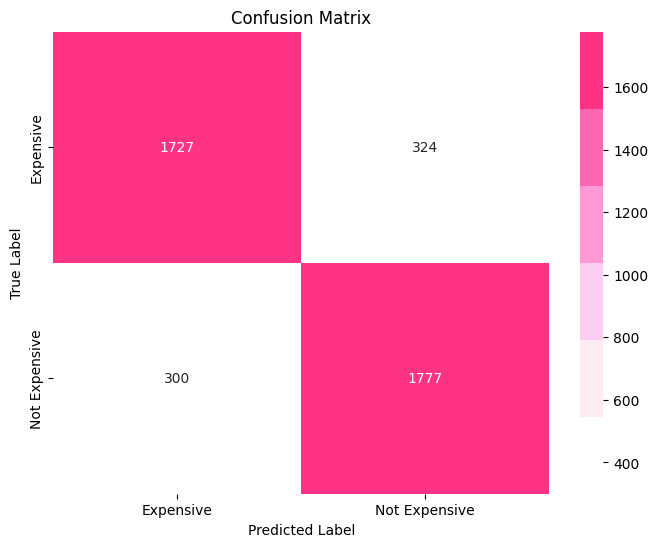

In [ ]:
# Plot confusion matrix
pink_colors = ['#ffffff', '#ffebf2', '#ffccf2', '#ff99d6', '#ff66b2', '#ff3385']
pink_cmap = ListedColormap(pink_colors)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap=pink_cmap)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
# Customize the x and y axis labels (0 -> 'Not Expensive', 1 -> 'Expensive')
plt.xticks([0.5, 1.5], ['Expensive','Not Expensive' ])
plt.yticks([0.5, 1.5], [ 'Expensive','Not Expensive'])

plt.show()

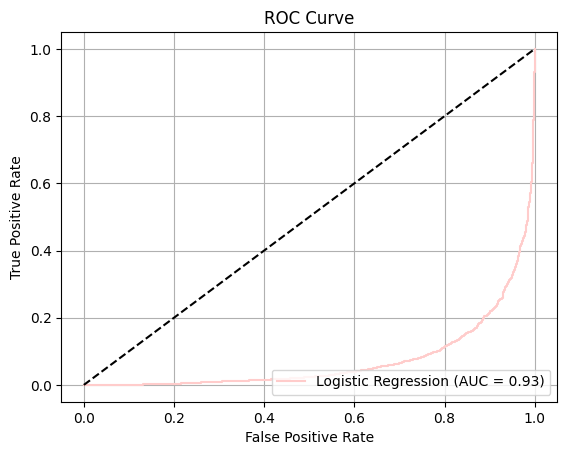

In [ ]:
# Plot ROC curve
plt.plot(fpr, tpr, color='#ffcccb', label=f'Logistic Regression (AUC = {roc_auc:.2f})')  # Baby pink
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Non-linear Regression

a) For this task, use the original continuous target variable (house prices).

b) Implement a polynomial regression model of degree 2 to predict house prices.

In [ ]:
poly_features = PolynomialFeatures(degree=2)
X_poly2 = poly_features.fit_transform(X)

c) Split the data into training and testing sets (use 80% for training, 20% for testing).

In [ ]:
# Split the data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly2, data['MedHouseVal'], test_size=0.2, random_state=42)

d) Train the model and make predictions on the test set.

In [ ]:
poly_model=LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)
# Make predictions
y_pred_poly=poly_model.predict(X_test_poly)

e) Evaluate the model's performance using
*  Mean Squared Error (MSE)
*   R-squared score




In [ ]:
mse_poly=mean_squared_error(y_test_poly, y_pred_poly)
# Calculate R-squared score
r2_poly=r2_score(y_test_poly, y_pred_poly)
# Print evaluation results
print("Mean Squared Error: {:.2f}".format(mse_poly))
print("R-squared Score: {:.2f}".format(r2_poly))

Mean Squared Error: 0.46
R-squared Score: 0.65


f) Plot the actual vs. predicted values for the Non-Linear Regression model Evaluate the model's performance.

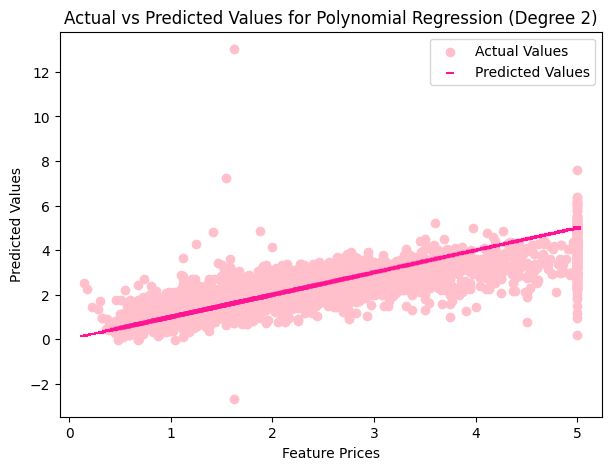

In [ ]:
# Plot the actual vs. predicted values
plt.figure(figsize=(7,5))

plt.scatter(y_test_poly, y_pred_poly, color='pink', label='Actual Values')
plt.scatter(y_test_poly, y_test_poly, color='deeppink', label='Predicted Values',marker='_')
plt.title('Actual vs Predicted Values for Polynomial Regression (Degree 2)')
plt.xlabel('Feature Prices')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()